# Evaluate ZINC12K GRASSY Training

This notebook visualizes:
1. Training loss curves
2. Latent space embeddings (PCA/PHATE) colored by molecular properties


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Paths to training outputs
loss_file = 'scripts/final_logs/ZINC12K_regress_nokld/ZINC12K_regress_nokld_reg_loss_list.npy'
embedding_file = 'scripts/final_logs/ZINC12K_regress_nokld/ordered_embedding_ZINC12K_regress_nokld.npy'
properties_file = 'scripts/final_logs/ZINC12K_regress_nokld/embedding_prop_lists_ZINC12K_regress_nokld.npy'

print("Checking files...")
for f in [loss_file, embedding_file, properties_file]:
    exists = Path(f).exists()
    print(f"  {f}: {'✅' if exists else '❌'}")


Checking files...
  scripts/final_logs/ZINC12K_regress_nokld/ZINC12K_regress_nokld_reg_loss_list.npy: ✅
  scripts/final_logs/ZINC12K_regress_nokld/ordered_embedding_ZINC12K_regress_nokld.npy: ✅
  scripts/final_logs/ZINC12K_regress_nokld/embedding_prop_lists_ZINC12K_regress_nokld.npy: ✅


## 1. Plot Training Loss


Loaded 9600 loss values
Loss range: [0.1156, 5.0828]
Final loss: 0.1525


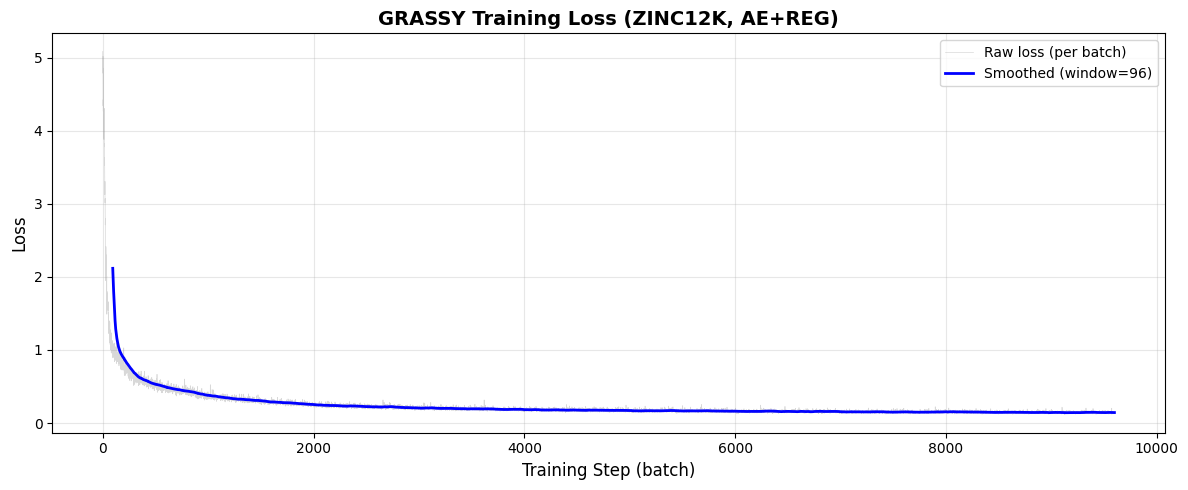


Loss Statistics:
  Initial (first 100 steps): 2.0710 ± 1.1968
  Final (last 100 steps): 0.1434 ± 0.0120
  Improvement: 93.1%


In [2]:
# Load loss history
losses = np.load(loss_file)
print(f"Loaded {len(losses)} loss values")
print(f"Loss range: [{losses.min():.4f}, {losses.max():.4f}]")
print(f"Final loss: {losses[-1]:.4f}")

# Plot raw loss
fig, ax = plt.subplots(figsize=(12, 5))

# Plot all losses (may be noisy)
ax.plot(losses, alpha=0.3, color='gray', label='Raw loss (per batch)', linewidth=0.5)

# Smooth with moving average for better visualization
window_size = max(1, len(losses) // 100)  # Adaptive window size
if window_size > 1:
    smoothed = np.convolve(losses, np.ones(window_size)/window_size, mode='valid')
    # Align smoothed array: mode='valid' starts from index (window_size - 1)
    x_smooth = np.arange(window_size - 1, len(losses))
    ax.plot(x_smooth, smoothed, color='blue', label=f'Smoothed (window={window_size})', linewidth=2)

ax.set_xlabel('Training Step (batch)', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('GRASSY Training Loss (ZINC12K, AE+REG)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print statistics
print(f"\nLoss Statistics:")
print(f"  Initial (first 100 steps): {losses[:100].mean():.4f} ± {losses[:100].std():.4f}")
print(f"  Final (last 100 steps): {losses[-100:].mean():.4f} ± {losses[-100:].std():.4f}")
print(f"  Improvement: {((losses[:100].mean() - losses[-100:].mean()) / losses[:100].mean() * 100):.1f}%")

In [4]:
import torch
import numpy as np
from datasets.load_ZINC_tranche import ZINCDataset, Scattering

# Load dataset to check scattering moment scales
TRANCH = "ZINC12K"
dataset = ZINCDataset(
    f'datasets/{TRANCH}.npy', 
    prop_stat_dict=f'datasets/{TRANCH}_stats.npy',
    transform=Scattering(scatter_model_name=f'scripts/trained_models/{TRANCH}.npy')
)

# Sample a few molecules to check scattering moment scales
print("=" * 60)
print("Scattering Moment Scale Analysis")
print("=" * 60)

sample_indices = [0, 100, 500, 1000]
scattering_moments = []

for idx in sample_indices:
    if idx < len(dataset):
        x, y = dataset[idx]
        scattering_moments.append(x.numpy())
        print(f"\nSample {idx}:")
        print(f"  Scattering moment shape: {x.shape}")
        print(f"  Min: {x.min():.4f}, Max: {x.max():.4f}, Mean: {x.mean():.4f}, Std: {x.std():.4f}")
        print(f"  L2 norm: {torch.norm(x).item():.4f}")

scattering_moments = np.array(scattering_moments)
print(f"\nOverall statistics (across {len(sample_indices)} samples):")
print(f"  Min: {scattering_moments.min():.4f}")
print(f"  Max: {scattering_moments.max():.4f}")
print(f"  Mean: {scattering_moments.mean():.4f}")
print(f"  Std: {scattering_moments.std():.4f}")

# Load model to check reconstruction quality
print("\n" + "=" * 60)
print("Reconstruction Quality Check")
print("=" * 60)

from models.GRASSY_model import GRASSY
from argparse import Namespace

# Load model state
model_path = 'scripts/final_logs/ZINC12K_regress_nokld/ZINC12K_regress_nokld_model.npy'
model_state = torch.load(model_path, map_location='cpu')

# Reconstruct model architecture (need to match training config)
# Get dimensions from first sample
sample_x, sample_y = dataset[0]
input_dim = len(sample_x)
num_properties = len(sample_y)

# Create model with same hyperparameters as training
hparams = Namespace(
    input_dim=input_dim,
    bottle_dim=25,
    hidden_dim=100,
    learning_rate=0.001,
    alpha=0.01,  # regression weight
    beta=0.0,   # KL weight (AE mode)
    n_epochs=100,
    len_epoch=None,
    batch_size=100,
    n_gpus=0,
    num_properties=num_properties
)

model = GRASSY(hparams=hparams)
model.load_state_dict(model_state)
model.eval()

# Test reconstruction on a few samples
print(f"\nTesting reconstruction on {len(sample_indices)} samples...")
recon_errors = []
reg_errors = []

with torch.no_grad():
    for idx in sample_indices[:4]:  # Test first 4
        if idx < len(dataset):
            x, y = dataset[idx]
            x_tensor = x.unsqueeze(0).float()
            y_tensor = torch.tensor(y).unsqueeze(0).float()
            
            x_hat, y_hat, mu, logvar, z = model(x_tensor)
            
            # Reconstruction error (MSE)
            recon_mse = torch.nn.MSELoss()(x_hat.flatten(), x_tensor.flatten()).item()
            recon_errors.append(recon_mse)
            
            # Regression error (MSE)
            reg_mse = torch.nn.MSELoss()(y_hat, y_tensor).item()
            reg_errors.append(reg_mse)
            
            # Relative reconstruction error
            x_norm = torch.norm(x_tensor).item()
            rel_error = np.sqrt(recon_mse) / x_norm if x_norm > 0 else 0
            
            print(f"\nSample {idx}:")
            print(f"  Reconstruction MSE: {recon_mse:.6f}")
            print(f"  Reconstruction RMSE: {np.sqrt(recon_mse):.6f}")
            print(f"  Original L2 norm: {x_norm:.4f}")
            print(f"  Relative error: {rel_error*100:.2f}%")
            print(f"  Regression MSE: {reg_mse:.6f}")

print(f"\n" + "=" * 60)
print("Summary")
print("=" * 60)
print(f"Average reconstruction MSE: {np.mean(recon_errors):.6f}")
print(f"Average reconstruction RMSE: {np.mean([np.sqrt(e) for e in recon_errors]):.6f}")
print(f"Average regression MSE: {np.mean(reg_errors):.6f}")
print(f"\nWith alpha={hparams.alpha}, the total loss components are:")
print(f"  recon_loss (unweighted): ~{np.mean(recon_errors):.6f}")
print(f"  reg_loss (weighted by alpha): ~{hparams.alpha * np.mean(reg_errors):.6f}")
print(f"  Total loss estimate: ~{np.mean(recon_errors) + hparams.alpha * np.mean(reg_errors):.6f}")
print(f"\nYour saved loss (~0.1) suggests:")
if np.mean(recon_errors) + hparams.alpha * np.mean(reg_errors) < 0.2:
    print("  ✅ Good reconstruction quality!")
else:
    print("  ⚠️  Reconstruction may need improvement")

Scattering Moment Scale Analysis

Sample 0:
  Scattering moment shape: torch.Size([440])
  Min: -2.1000, Max: 24.0357, Mean: 1.3285, Std: 3.2302
  L2 norm: 73.1917

Sample 100:
  Scattering moment shape: torch.Size([440])
  Min: -2.0412, Max: 16.0500, Mean: 0.6307, Std: 1.6427
  L2 norm: 36.8732

Sample 500:
  Scattering moment shape: torch.Size([440])
  Min: -3.0000, Max: 7.5870, Mean: 0.4719, Std: 1.4861
  L2 norm: 32.6736

Sample 1000:
  Scattering moment shape: torch.Size([440])
  Min: -3.0000, Max: 17.0476, Mean: 0.9694, Std: 2.3842
  L2 norm: 53.9353

Overall statistics (across 4 samples):
  Min: -3.0000
  Max: 24.0357
  Mean: 0.8501
  Std: 2.3137

Reconstruction Quality Check

Testing reconstruction on 4 samples...

Sample 0:
  Reconstruction MSE: 0.216834
  Reconstruction RMSE: 0.465654
  Original L2 norm: 73.1917
  Relative error: 0.64%
  Regression MSE: 0.163286

Sample 100:
  Reconstruction MSE: 0.106333
  Reconstruction RMSE: 0.326087
  Original L2 norm: 36.8732
  Relative 

C:\Users\stolk\AppData\Local\Temp\ipykernel_38724\2536204775.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_state = torch.load(model_path, map_location='cpu')
C:

## 2. Visualize Latent Space Embeddings


In [6]:
# Run the visualization script
import subprocess
import os

# Create output directory
outdir = 'figs/zinc12k_evaluation'
os.makedirs(outdir, exist_ok=True)

# Run visualization
cmd = [
    'python', 'visualize_latent_embeddings.py',
    '--embedding', embedding_file,
    '--labels', properties_file,
    '--outdir', outdir,
    '--no-show'  # Don't show interactively in notebook
]

print("Running visualization script...")
print(f"Command: {' '.join(cmd)}")
print()

result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout)
if result.stderr:
    print("Errors/Warnings:")
    print(result.stderr)

if result.returncode == 0:
    print("\n✅ Visualization complete!")
    print(f"Figures saved to: {outdir}")
    
    # List generated files
    fig_files = list(Path(outdir).glob('*.png'))
    if fig_files:
        print("\nGenerated figures:")
        for f in sorted(fig_files):
            print(f"  - {f.name}")
else:
    print(f"\n❌ Visualization failed with return code {result.returncode}")


Running visualization script...
Command: python visualize_latent_embeddings.py --embedding scripts/final_logs/ZINC12K_regress_nokld/ordered_embedding_ZINC12K_regress_nokld.npy --labels scripts/final_logs/ZINC12K_regress_nokld/embedding_prop_lists_ZINC12K_regress_nokld.npy --outdir figs/zinc12k_evaluation --no-show

Loading embedding: scripts/final_logs/ZINC12K_regress_nokld/ordered_embedding_ZINC12K_regress_nokld.npy
Embedding shape: (11994, 25)
Loading labels: scripts/final_logs/ZINC12K_regress_nokld/embedding_prop_lists_ZINC12K_regress_nokld.npy
Labels shape: (11994, 4)
Computing PCA...
Explained variance ratio (PCA): [0.28142816 0.15374345]
Computing PHATE...
Calculating PHATE...
  Running PHATE on 11994 observations and 25 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 8.29 seconds.
    Calculating affinities...
    Calculated affinities in 1.37 seconds.
  Calculated graph and diffusion operator in 11.14 seconds.


Found 8 figure(s):

📊 latent_pca_prop1.png


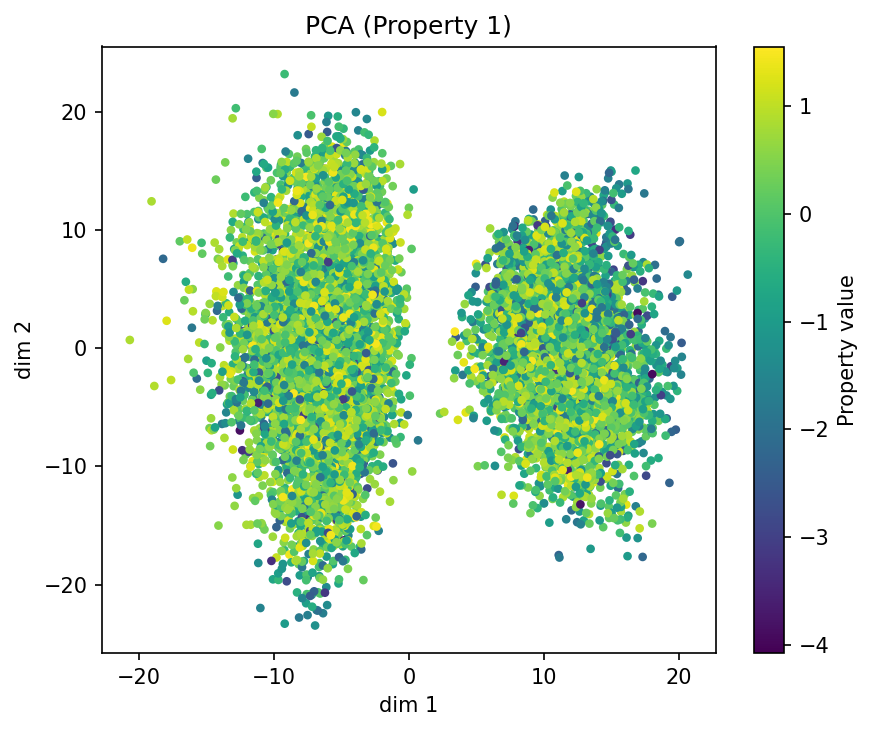


📊 latent_pca_prop2.png


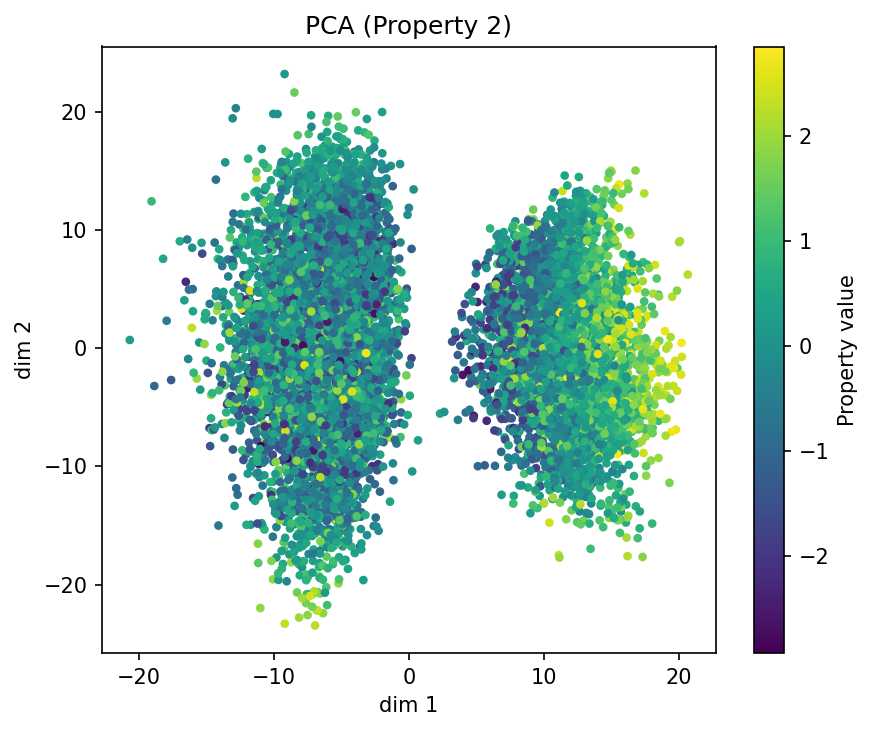


📊 latent_pca_prop3.png


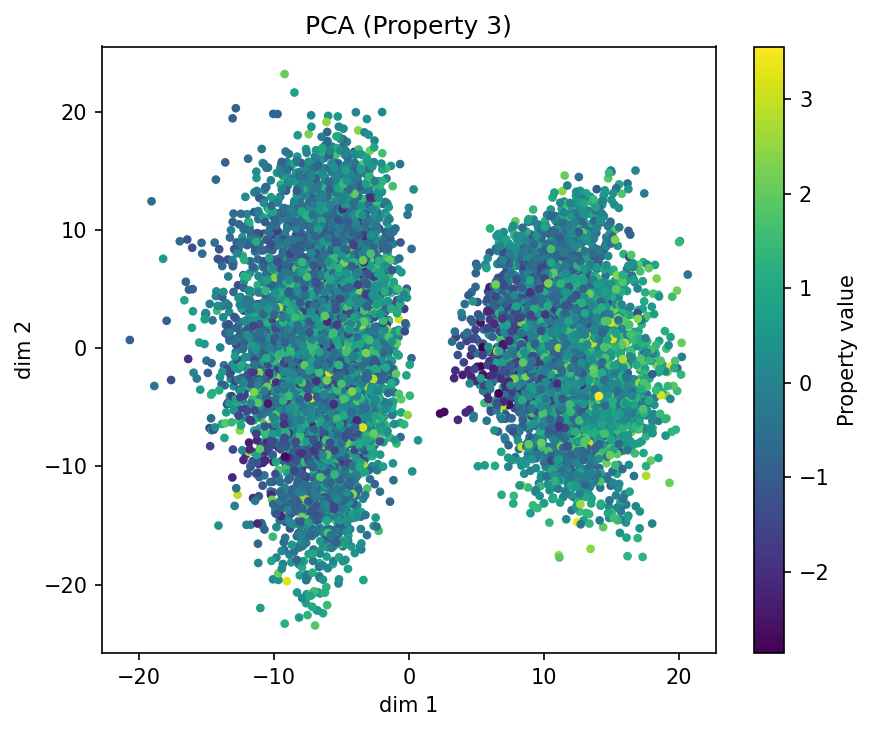


📊 latent_pca_prop4.png


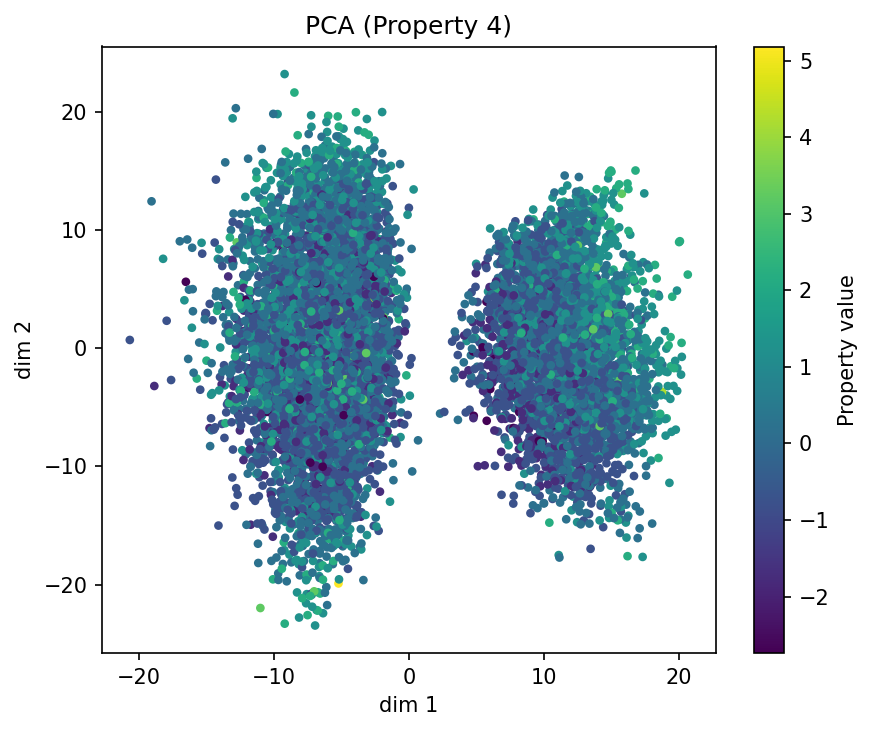


📊 latent_phate_prop1.png


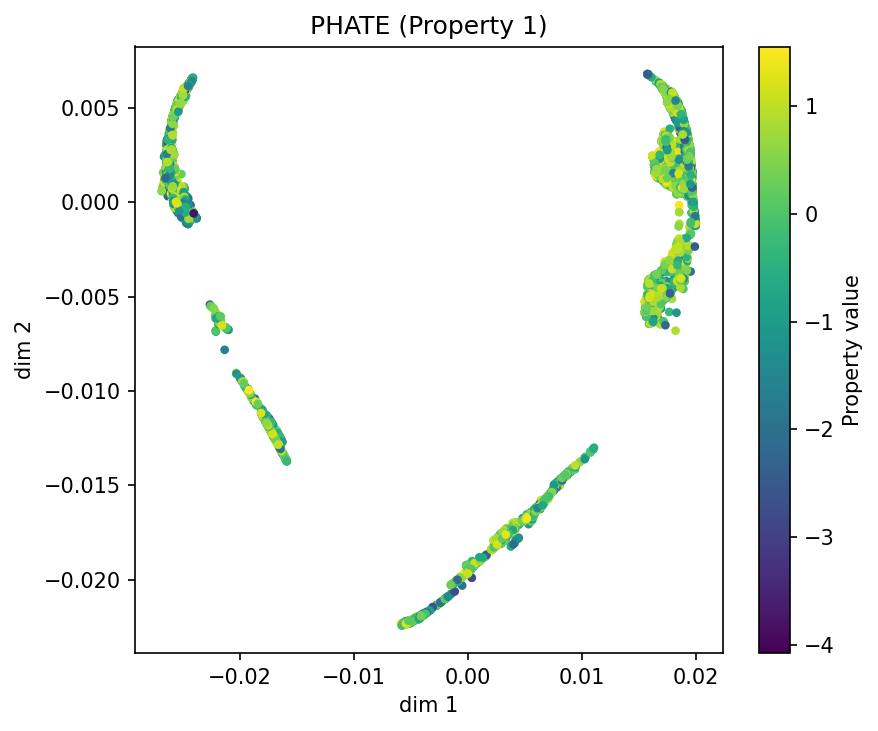


📊 latent_phate_prop2.png


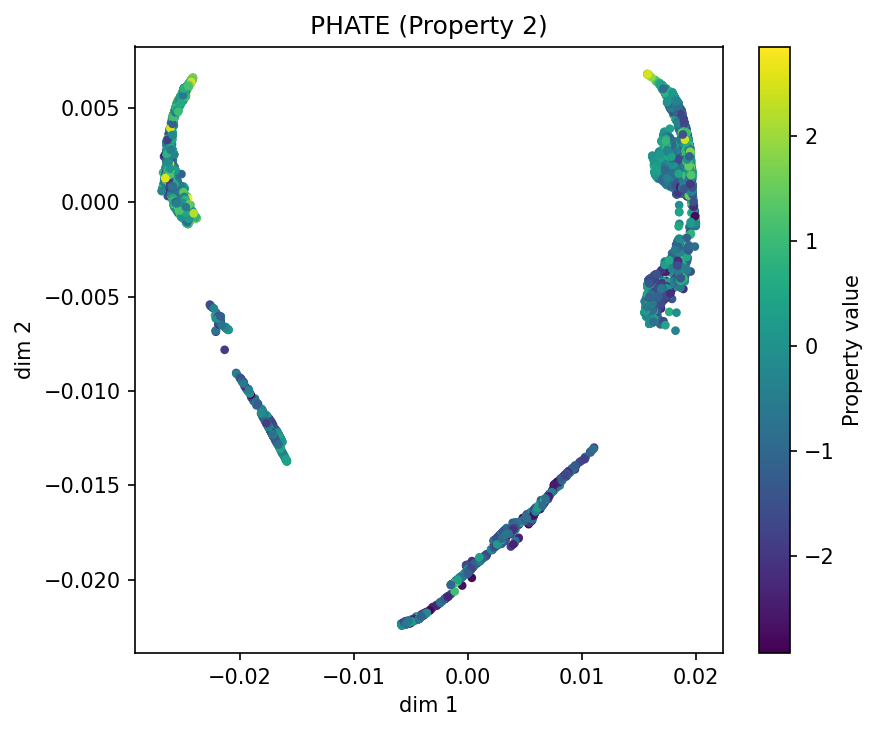


📊 latent_phate_prop3.png


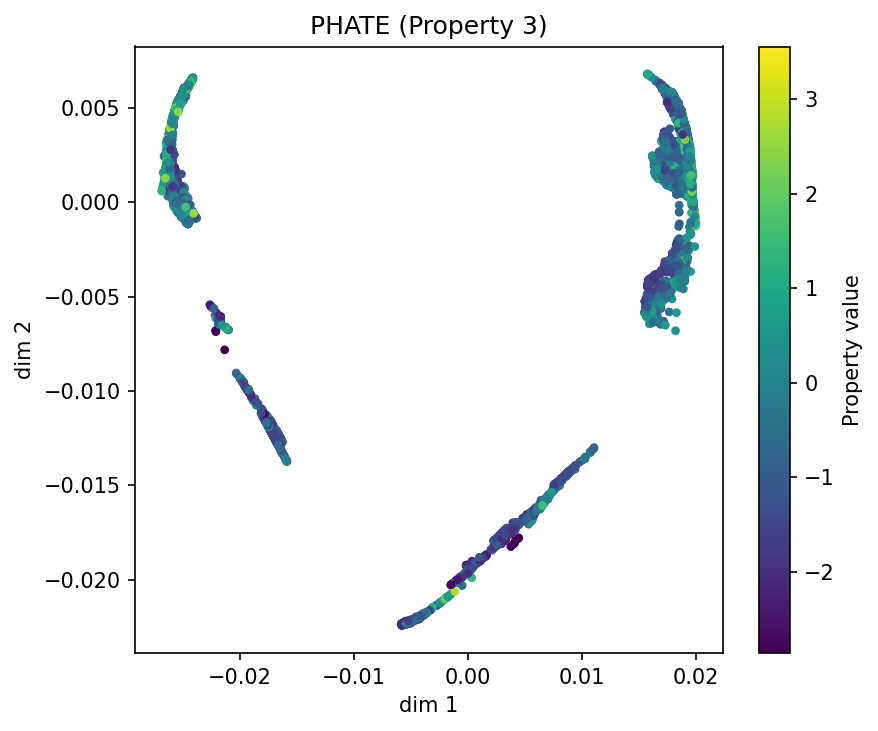


📊 latent_phate_prop4.png


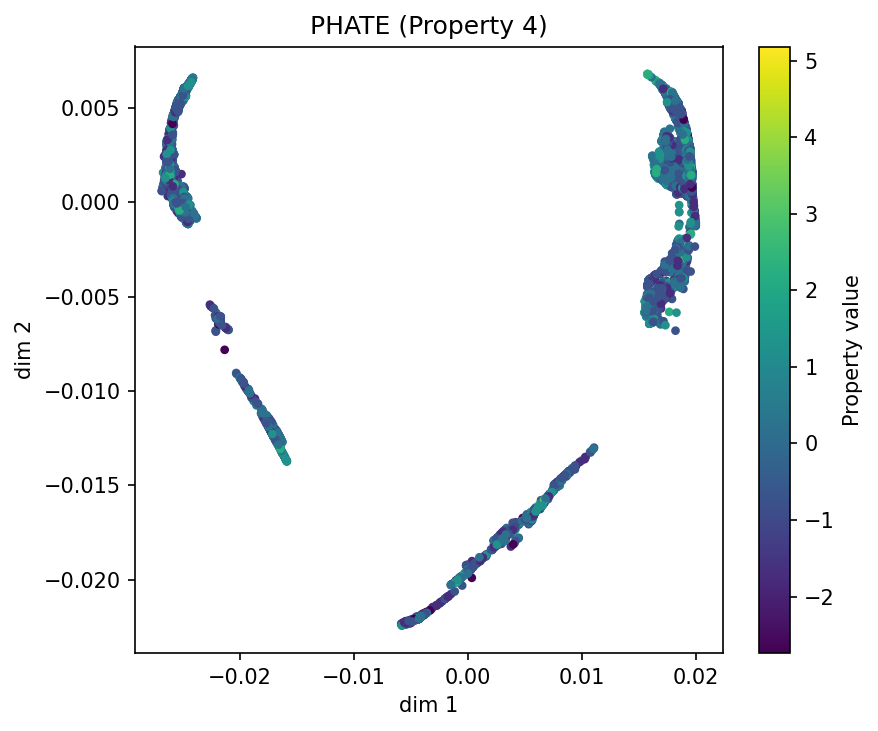

In [7]:
# Display the generated figures
from IPython.display import Image, display
import glob

fig_files = sorted(glob.glob(f'{outdir}/*.png'))
if fig_files:
    print(f"Found {len(fig_files)} figure(s):\n")
    for fig_path in fig_files:
        print(f"📊 {Path(fig_path).name}")
        display(Image(fig_path))
        print()
else:
    print(f"No figures found in {outdir}")


## 3. Additional Analysis: Embedding Statistics


In [5]:
# Load embeddings and properties for additional analysis
embeddings = np.load(embedding_file)
props = np.load(properties_file, allow_pickle=True)

print(f"Embedding shape: {embeddings.shape}")
print(f"  - {embeddings.shape[0]} molecules")
print(f"  - {embeddings.shape[1]} latent dimensions")

print(f"\nProperty lists shape: {props.shape if hasattr(props, 'shape') else 'list'}")
if isinstance(props, np.ndarray) and props.ndim > 0:
    print(f"  - {len(props)} properties tracked")
    for i, prop_name in enumerate(['QED', 'HeavyAtomMolWt', 'TPSA', 'RingCount']):
        if i < len(props):
            prop_vals = props[i]
            print(f"  - {prop_name}: {len(prop_vals)} values, range=[{np.min(prop_vals):.2f}, {np.max(prop_vals):.2f}]")

# Check for any NaN or Inf values
print(f"\nData quality checks:")
print(f"  Embeddings - NaN: {np.isnan(embeddings).sum()}, Inf: {np.isinf(embeddings).sum()}")
if isinstance(props, np.ndarray):
    print(f"  Properties - NaN: {np.isnan(props).sum() if props.dtype != object else 'N/A'}, Inf: {np.isinf(props).sum() if props.dtype != object else 'N/A'}")

# Embedding statistics
print(f"\nEmbedding statistics:")
print(f"  Mean: {embeddings.mean(axis=0)[:5]}... (showing first 5 dims)")
print(f"  Std:  {embeddings.std(axis=0)[:5]}... (showing first 5 dims)")
print(f"  Min:  {embeddings.min(axis=0)[:5]}... (showing first 5 dims)")
print(f"  Max:  {embeddings.max(axis=0)[:5]}... (showing first 5 dims)")


Embedding shape: (11994, 25)
  - 11994 molecules
  - 25 latent dimensions

Property lists shape: (4, 11994)
  - 4 properties tracked
  - QED: 11994 values, range=[-4.08, 1.56]
  - HeavyAtomMolWt: 11994 values, range=[-2.93, 2.86]
  - TPSA: 11994 values, range=[-2.86, 3.56]
  - RingCount: 11994 values, range=[-2.74, 5.19]

Data quality checks:
  Embeddings - NaN: 0, Inf: 0
  Properties - NaN: 0, Inf: 0

Embedding statistics:
  Mean: [ 0.7122758  -0.16533965  1.3895433  -0.9988492  -0.41507146]... (showing first 5 dims)
  Std:  [3.4243815 3.237749  3.2574844 3.7897928 3.1322348]... (showing first 5 dims)
  Min:  [-10.07021  -14.720403 -11.987263 -12.294424 -15.776574]... (showing first 5 dims)
  Max:  [22.706846 10.451743 14.715792 12.473549 11.120662]... (showing first 5 dims)
